In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
modeling_data = pd.read_csv('final_youtube.csv')
modeling_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17586 entries, 0 to 17585
Data columns (total 71 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                17586 non-null  int64  
 1   views                     17586 non-null  int64  
 2   likes                     17586 non-null  int64  
 3   comments                  17586 non-null  int64  
 4   duration_log              17586 non-null  float64
 5   bitrate_log               17586 non-null  float64
 6   height_log                17586 non-null  float64
 7   width_log                 17586 non-null  float64
 8   frame rate_log            17586 non-null  float64
 9   views_log                 17586 non-null  float64
 10  likes_log                 17586 non-null  float64
 11  comments_log              17586 non-null  float64
 12  likes_log_win             17586 non-null  float64
 13  comments_log_win          17586 non-null  float64
 14  durati

# Loại bỏ các cột có thể dẫn đến data leakage

In [ ]:
leakage_features = [
    'views', 'comments'
    'likes_log',
    'likes_log_win',

    'likes_log_scaled', 'likes_log_minmax', 'likes_log_zscore',
    'likes_log_win_scaled', 'likes_log_win_minmax', 'likes_log_win_zscore',

    'Unnamed: 0',
]

existing_leakage = [col for col in leakage_features if col in modeling_data.columns]
df_clean = modeling_data.drop(columns=existing_leakage, errors='ignore')

print(f"Removed {len(existing_leakage)} leakage features")
print(f"Remaining: {df_clean.shape[1]} columns")

Removed 9 leakage features
Remaining: 62 columns


# Giữ lại 1 loại chuẩn hoá cho biến số, tránh multicollinearity

In [ ]:
# Ưu tiên giữ _scaled, loại _minmax và _zscore
duplicate_features = []

for col in df_clean.columns:
    if '_minmax' in col:
        duplicate_features.append(col)
    elif '_zscore' in col:
        scaled_version = col.replace('_zscore', '_scaled')
        if scaled_version in df_clean.columns:
            duplicate_features.append(col)

df_clean = df_clean.drop(columns=duplicate_features, errors='ignore')

print(f"Removed {len(duplicate_features)} duplicate transforms")
print(f"Remaining: {df_clean.shape[1]} columns")

Removed 14 duplicate transforms
Remaining: 48 columns


# Chuẩn bị data cho huấn luyện

In [ ]:
# Target
y = df_clean['likes_log']

# Features
X = df_clean.drop(columns=['likes_log', 'likes'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
print(f"Split ratio: 80/20")

X shape: (17586, 46)
y shape: (17586,)
Train set: (14068, 46)
Test set:  (3518, 46)
Split ratio: 80/20


# Tạo pipeline huấn luyện

In [ ]:
pipeline = Pipeline([
    ("poly", PolynomialFeatures(
        degree=2,
        interaction_only=True,
        include_bias=False
    )),
    ("linear", LinearRegression())
])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)


In [ ]:
y_train_pred_log = pipeline.predict(X_train)
y_test_pred_log = pipeline.predict(X_test)

y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

# Đánh giá trên tập kiểm thử và huấn luyện

In [ ]:
r2_train_log = r2_score(y_train, y_train_pred_log)
r2_test_log = r2_score(y_test, y_test_pred_log)
mse_train_log = mean_squared_error(y_train, y_train_pred_log)
mse_test_log = mean_squared_error(y_test, y_test_pred_log)
mae_train_log = mean_absolute_error(y_train, y_train_pred_log)
mae_test_log = mean_absolute_error(y_test, y_test_pred_log)

print(f"{'Metric':<20s} {'Train':>15s} {'Test':>15s}")
print("-" * 60)
print(f"{'R² Score':<20s} {r2_train_log:>15.4f} {r2_test_log:>15.4f}")
print(f"{'MSE':<20s} {mse_train_log:>15.4f} {mse_test_log:>15.4f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_log):>15.4f} {np.sqrt(mse_test_log):>15.4f}")
print(f"{'MAE':<20s} {mae_train_log:>15.4f} {mae_test_log:>15.4f}")

overfit = r2_train_log - r2_test_log
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>15.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

Metric                         Train            Test
------------------------------------------------------------
R² Score                      0.8553          0.8056
MSE                           0.3615          0.4617
RMSE                          0.6012          0.6795
MAE                           0.4372          0.4683

Overfit (R² diff)             0.0497
   ✅ Model generalize tốt


# Plot đánh giá

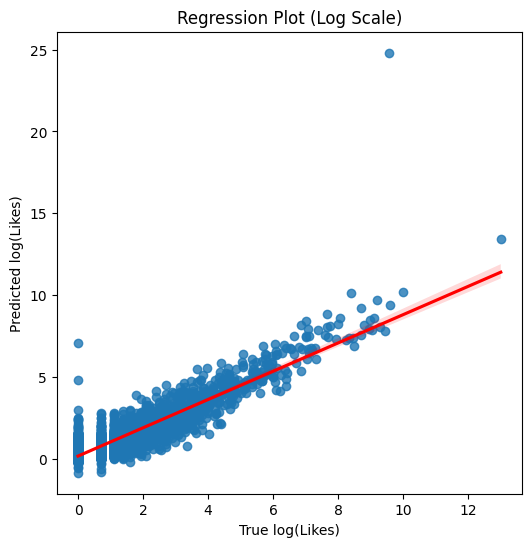

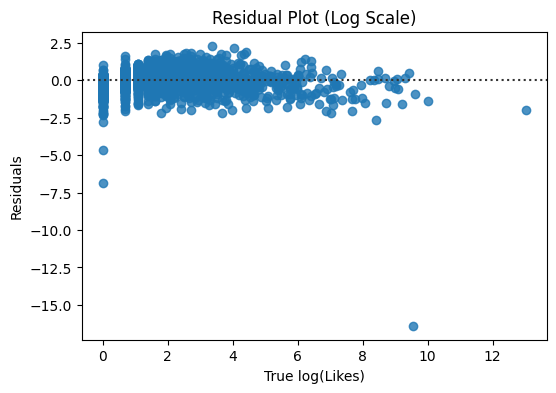

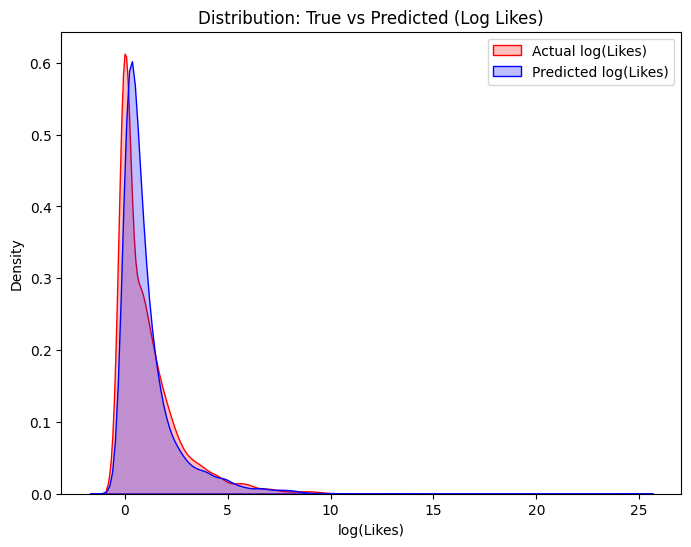

In [ ]:
y_true = y_test
y_pred = y_pred
residuals = y_true - y_pred

# ----- Regression plot (log scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true, y=y_pred, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Predicted log(Likes)")
plt.title("Regression Plot (Log Scale)")
plt.show()

# ----- Residual plot (log scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true, y=residuals, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.show()

# ----- Distribution comparison -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true, color='red', label='Actual log(Likes)', shade=True)
sns.kdeplot(y_pred, color='blue', label='Predicted log(Likes)', shade=True)
plt.title('Distribution: True vs Predicted (Log Likes)')
plt.xlabel('log(Likes)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Tuning với GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'poly__degree': [1, 2, 3],
}

# GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .....................................poly__degree=1; total time=   0.0s
[CV] END .....................................poly__degree=1; total time=   0.0s
[CV] END .....................................poly__degree=1; total time=   0.0s
[CV] END .....................................poly__degree=1; total time=   0.0s
[CV] END .....................................poly__degree=1; total time=   0.0s
[CV] END .....................................poly__degree=2; total time=   4.7s
[CV] END .....................................poly__degree=2; total time=   2.5s
[CV] END .....................................poly__degree=2; total time=   2.5s
[CV] END .....................................poly__degree=2; total time=   2.5s
[CV] END .....................................poly__degree=2; total time=   2.9s
[CV] END .....................................poly__degree=3; total time=23.0min
[CV] END .....................................pol

In [ ]:
y_train_pred_log = best_pipeline.predict(X_train)
y_test_pred_log = best_pipeline.predict(X_test)

y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

In [ ]:
r2_train_log = r2_score(y_train, y_train_pred_log)
r2_test_log = r2_score(y_test, y_test_pred_log)
mse_train_log = mean_squared_error(y_train, y_train_pred_log)
mse_test_log = mean_squared_error(y_test, y_test_pred_log)
mae_train_log = mean_absolute_error(y_train, y_train_pred_log)
mae_test_log = mean_absolute_error(y_test, y_test_pred_log)

print(f"{'Metric':<20s} {'Train':>15s} {'Test':>15s}")
print("-" * 60)
print(f"{'R² Score':<20s} {r2_train_log:>15.4f} {r2_test_log:>15.4f}")
print(f"{'MSE':<20s} {mse_train_log:>15.4f} {mse_test_log:>15.4f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_log):>15.4f} {np.sqrt(mse_test_log):>15.4f}")
print(f"{'MAE':<20s} {mae_train_log:>15.4f} {mae_test_log:>15.4f}")

overfit = r2_train_log - r2_test_log
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>15.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

Metric                         Train            Test
------------------------------------------------------------
R² Score                      0.8112          0.7936
MSE                           0.4715          0.4903
RMSE                          0.6866          0.7002
MAE                           0.5150          0.5297

Overfit (R² diff)             0.0177
   ✅ Model generalize tốt


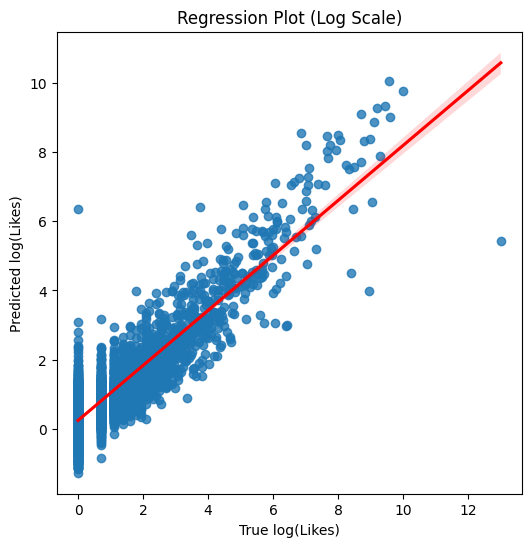

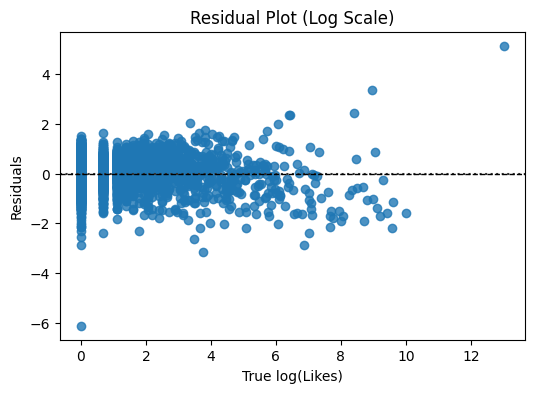

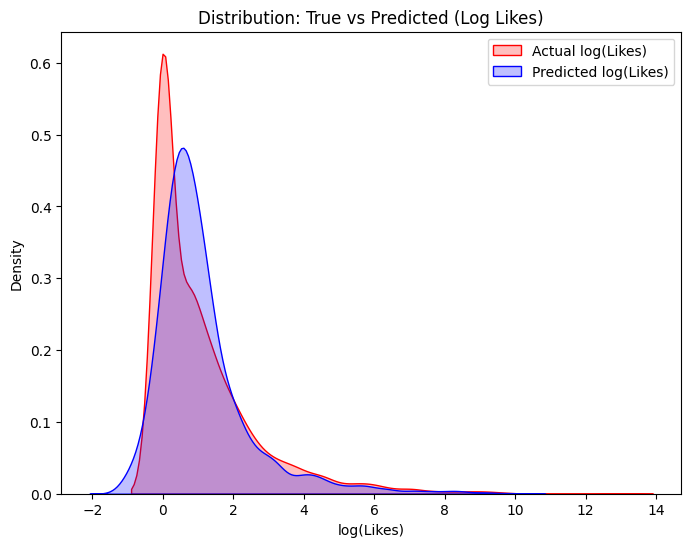

In [ ]:
y_true = y_test
y_pred = y_test_pred_log
residuals = y_true - y_pred

plt.figure(figsize=(6,6))
sns.regplot(x=y_true, y=y_pred, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Predicted log(Likes)")
plt.title("Regression Plot (Log Scale)")
plt.show()

plt.figure(figsize=(6,4))
sns.residplot(x=y_true, y=residuals, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.show()

plt.figure(figsize=(8,6))
sns.kdeplot(y_true, color='red', label='Actual log(Likes)', shade=True)
sns.kdeplot(y_pred, color='blue', label='Predicted log(Likes)', shade=True)
plt.title('Distribution: True vs Predicted (Log Likes)')
plt.xlabel('log(Likes)')
plt.ylabel('Density')
plt.legend()
plt.show()